In [1]:
import os, sys
PROJECT_ROOT = os.path.abspath("..")  # 从 notebook/ 回到项目根目录
sys.path.insert(0, PROJECT_ROOT)

DATA_DIR = os.path.join(PROJECT_ROOT, "IEEE")
LOG_DIR  = os.path.join(PROJECT_ROOT, "log")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("LOG_DIR:", LOG_DIR)

PROJECT_ROOT: /root/ADHD-EEG-ViT-myversion
DATA_DIR: /root/ADHD-EEG-ViT-myversion/IEEE
LOG_DIR: /root/ADHD-EEG-ViT-myversion/log


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from utils import (
    ignore_warnings,
    fix_random_seed,
    device,
    clear_cache,
    join_drive_path,
    log_json,
    train_with_kfold,
    WarmupScheduler,
    evaluate,
    Config,
    IEEEDataConfig,
    EEGDataset,
)
from models.transformer import TransformerConfig, ViTransformer

ignore_warnings()
fix_random_seed(42)
#device = device(force_cuda=True)
#print("Device:", device)
device = device(force_cuda=torch.cuda.is_available())
print("Device:", device)

Device: cuda


In [3]:
config = Config(
    name="ieee transformer",
    batch=8,
    epochs=50,
    lr=1e-3,
    enable_fp16=True,
    grad_step=4,
    warmup_steps=30,
    lr_decay_factor=0.5,
    weight_decay=1e-3,
    patience=30,
)
config.add(k_folds=5)
data_config = IEEEDataConfig()
model_config = TransformerConfig(
    embed_dim=64,
    num_heads=4,
    num_blocks=4,
    block_hidden_dim=128,
    fc_hidden_dim=32,
    dropout=0.1,
)

print("ID:", config.id)
print("Name:", config.name)

ID: 260309213635618066
Name: ieee-transformer


In [4]:
train_data_path = os.path.join(DATA_DIR, data_config.train)  # train.pt
val_data_path   = os.path.join(DATA_DIR, data_config.val)    # val.pt

train_data = torch.load(train_data_path, weights_only=True)
val_data = torch.load(val_data_path, weights_only=True)

# Concat Train-set and Validation-set for Cross validation
signals = torch.cat([train_data["data"], val_data["data"]], dim=0)
labels = torch.cat([train_data["label"], val_data["label"]], dim=0)

train_dataset = EEGDataset({"data": signals, "label": labels})

In [5]:
model_param = {
    "input_channel": data_config.channels,
    "seq_length": data_config.length,
    "embed_dim": model_config.embed_dim,
    "num_heads": model_config.num_heads,
    "num_blocks": model_config.num_blocks,
    "block_hidden_dim": model_config.block_hidden_dim,
    "fc_hidden_dim": model_config.fc_hidden_dim,
    "num_classes": data_config.num_classes,
    "dropout_p": model_config.dropout,
    
    #"use_channel_attn": False,
   
    "use_channel_attn": True,           #3.5channelattention动态态
    "channel_attn_type": "dynamic",
    "channel_attn_reduction": 4,

    # "use_channel_attn": True,           #3.5channelattention静态
    # "channel_attn_type": "static",
}

criterion = nn.CrossEntropyLoss()
check_point, best_model_path, fold_results = train_with_kfold(          #3.9比原句多加了一个“fold_results”打印每个fold结果
    k_folds=config.k_folds,
    model_class=ViTransformer,
    device=device,
    model_path=config.model_path,
    optimizer_class=optim.Adam,
    criterion=criterion,
    epochs=config.epochs,
    train_dataset=train_dataset,
    batch=config.batch,
    gradient_step=config.grad_step,
    patience=config.patience,
    model_params=model_param,
    optimizer_params={"lr": config.lr, "weight_decay": config.weight_decay},
    enable_fp16=config.enable_fp16,
    scheduler_class=WarmupScheduler,
    scheduler_params={
        "lr": config.lr,
        "warmup_steps": config.warmup_steps,
        "decay_factor": config.lr_decay_factor,
    },
)



===== Fold 1 =====


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch 001 | Train-Loss: 0.74846 | Train-Acc: 0.5545 | Val-Loss: 0.60279 | Val-Acc: 0.7143
Epoch 002 | Train-Loss: 0.73764 | Train-Acc: 0.5545 | Val-Loss: 0.60823 | Val-Acc: 0.7143
Epoch 003 | Train-Loss: 0.69262 | Train-Acc: 0.5818 | Val-Loss: 0.62074 | Val-Acc: 0.7143
Epoch 004 | Train-Loss: 0.68490 | Train-Acc: 0.6091 | Val-Loss: 0.64090 | Val-Acc: 0.7143
Epoch 005 | Train-Loss: 0.69892 | Train-Acc: 0.5545 | Val-Loss: 0.65480 | Val-Acc: 0.7143
Epoch 006 | Train-Loss: 0.66055 | Train-Acc: 0.6818 | Val-Loss: 0.66410 | Val-Acc: 0.7143
Epoch 007 | Train-Loss: 0.67760 | Train-Acc: 0.5364 | Val-Loss: 0.67252 | Val-Acc: 0.6786
Epoch 008 | Train-Loss: 0.66722 | Train-Acc: 0.5818 | Val-Loss: 0.66074 | Val-Acc: 0.7143
Epoch 009 | Train-Loss: 0.65262 | Train-Acc: 0.6455 | Val-Loss: 0.64244 | Val-Acc: 0.7143
Epoch 010 | Train-Loss: 0.65067 | Train-Acc: 0.6000 | Val-Loss: 0.62401 | Val-Acc: 0.7143
Epoch 011 | Train-Loss: 0.63975 | Train-Acc: 0.6818 | Val-Loss: 0.61059 | Val-Acc: 0.7143
Epoch 012 

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch 001 | Train-Loss: 0.90763 | Train-Acc: 0.4273 | Val-Loss: 0.81116 | Val-Acc: 0.4643
Epoch 002 | Train-Loss: 0.91446 | Train-Acc: 0.4000 | Val-Loss: 0.76142 | Val-Acc: 0.4643
Epoch 003 | Train-Loss: 0.79822 | Train-Acc: 0.4636 | Val-Loss: 0.71049 | Val-Acc: 0.4643
Epoch 004 | Train-Loss: 0.69985 | Train-Acc: 0.5273 | Val-Loss: 0.68401 | Val-Acc: 0.6429
Epoch 005 | Train-Loss: 0.69692 | Train-Acc: 0.5364 | Val-Loss: 0.69354 | Val-Acc: 0.5357
Epoch 006 | Train-Loss: 0.66068 | Train-Acc: 0.5818 | Val-Loss: 0.72351 | Val-Acc: 0.5357
Epoch 007 | Train-Loss: 0.66127 | Train-Acc: 0.6091 | Val-Loss: 0.74506 | Val-Acc: 0.5357
Epoch 008 | Train-Loss: 0.65690 | Train-Acc: 0.6091 | Val-Loss: 0.73139 | Val-Acc: 0.5357
Epoch 009 | Train-Loss: 0.65405 | Train-Acc: 0.5909 | Val-Loss: 0.69484 | Val-Acc: 0.5357
Epoch 010 | Train-Loss: 0.63351 | Train-Acc: 0.6455 | Val-Loss: 0.66458 | Val-Acc: 0.5357
Epoch 011 | Train-Loss: 0.57921 | Train-Acc: 0.7455 | Val-Loss: 0.64524 | Val-Acc: 0.6429
Epoch 012 

...

Epoch 001 | Train-Loss: 0.80594 | Train-Acc: 0.4364 | Val-Loss: 0.82427 | Val-Acc: 0.3571
Epoch 002 | Train-Loss: 0.77406 | Train-Acc: 0.4364 | Val-Loss: 0.78723 | Val-Acc: 0.3571
Epoch 003 | Train-Loss: 0.75256 | Train-Acc: 0.4091 | Val-Loss: 0.74766 | Val-Acc: 0.3571
Epoch 004 | Train-Loss: 0.72280 | Train-Acc: 0.4545 | Val-Loss: 0.70917 | Val-Acc: 0.4643
Epoch 005 | Train-Loss: 0.72354 | Train-Acc: 0.4909 | Val-Loss: 0.68536 | Val-Acc: 0.6429
Epoch 006 | Train-Loss: 0.69667 | Train-Acc: 0.5818 | Val-Loss: 0.67502 | Val-Acc: 0.6429
Epoch 007 | Train-Loss: 0.69528 | Train-Acc: 0.5545 | Val-Loss: 0.66906 | Val-Acc: 0.6429
Epoch 008 | Train-Loss: 0.68355 | Train-Acc: 0.5818 | Val-Loss: 0.66382 | Val-Acc: 0.6429
Epoch 009 | Train-Loss: 0.66893 | Train-Acc: 0.5636 | Val-Loss: 0.66301 | Val-Acc: 0.6429
Epoch 010 | Train-Loss: 0.65632 | Train-Acc: 0.6364 | Val-Loss: 0.66069 | Val-Acc: 0.6429
Epoch 011 | Train-Loss: 0.63228 | Train-Acc: 0.6636 | Val-Loss: 0.66053 | Val-Acc: 0.6429
Epoch 012 

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch 001 | Train-Loss: 0.76447 | Train-Acc: 0.6036 | Val-Loss: 0.80116 | Val-Acc: 0.5185
Epoch 002 | Train-Loss: 0.72997 | Train-Acc: 0.5946 | Val-Loss: 0.77273 | Val-Acc: 0.5185
Epoch 003 | Train-Loss: 0.73782 | Train-Acc: 0.5946 | Val-Loss: 0.73823 | Val-Acc: 0.5185
Epoch 004 | Train-Loss: 0.70390 | Train-Acc: 0.6126 | Val-Loss: 0.70933 | Val-Acc: 0.5185
Epoch 005 | Train-Loss: 0.70356 | Train-Acc: 0.5405 | Val-Loss: 0.68650 | Val-Acc: 0.5185
Epoch 006 | Train-Loss: 0.65373 | Train-Acc: 0.6126 | Val-Loss: 0.67418 | Val-Acc: 0.5185
Epoch 007 | Train-Loss: 0.65071 | Train-Acc: 0.6306 | Val-Loss: 0.66646 | Val-Acc: 0.5185
Epoch 008 | Train-Loss: 0.62886 | Train-Acc: 0.6667 | Val-Loss: 0.66538 | Val-Acc: 0.5556
Epoch 009 | Train-Loss: 0.62016 | Train-Acc: 0.6577 | Val-Loss: 0.66463 | Val-Acc: 0.5185
Epoch 010 | Train-Loss: 0.60026 | Train-Acc: 0.6937 | Val-Loss: 0.66142 | Val-Acc: 0.5185
Epoch 011 | Train-Loss: 0.60016 | Train-Acc: 0.6757 | Val-Loss: 0.65431 | Val-Acc: 0.5185
Epoch 012 

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch 001 | Train-Loss: 0.71731 | Train-Acc: 0.5586 | Val-Loss: 0.77945 | Val-Acc: 0.5185
Epoch 002 | Train-Loss: 0.68021 | Train-Acc: 0.6036 | Val-Loss: 0.76319 | Val-Acc: 0.5185
Epoch 003 | Train-Loss: 0.68980 | Train-Acc: 0.6126 | Val-Loss: 0.74281 | Val-Acc: 0.5185
Epoch 004 | Train-Loss: 0.67081 | Train-Acc: 0.6036 | Val-Loss: 0.72871 | Val-Acc: 0.5185
Epoch 005 | Train-Loss: 0.65503 | Train-Acc: 0.6126 | Val-Loss: 0.71790 | Val-Acc: 0.5185
Epoch 006 | Train-Loss: 0.68534 | Train-Acc: 0.5946 | Val-Loss: 0.71152 | Val-Acc: 0.5185
Epoch 007 | Train-Loss: 0.64781 | Train-Acc: 0.6126 | Val-Loss: 0.71221 | Val-Acc: 0.5185
Epoch 008 | Train-Loss: 0.64335 | Train-Acc: 0.6036 | Val-Loss: 0.70083 | Val-Acc: 0.5185
Epoch 009 | Train-Loss: 0.62938 | Train-Acc: 0.6126 | Val-Loss: 0.69642 | Val-Acc: 0.5185
Epoch 010 | Train-Loss: 0.60985 | Train-Acc: 0.6486 | Val-Loss: 0.68768 | Val-Acc: 0.5185
Epoch 011 | Train-Loss: 0.61338 | Train-Acc: 0.6486 | Val-Loss: 0.66938 | Val-Acc: 0.5556
Epoch 012 

===== Fold Results =====
Fold 1 | best_epoch=39 | val_loss=0.429378 | val_acc=0.8571
Fold 2 | best_epoch=48 | val_loss=0.354643 | val_acc=0.8571
Fold 3 | best_epoch=27 | val_loss=0.517764 | val_acc=0.7857
Fold 4 | best_epoch=32 | val_loss=0.286243 | val_acc=0.8519
Fold 5 | best_epoch=40 | val_loss=0.222626 | val_acc=0.8889

===== Cross-validation Mean ± Std =====
val_loss: 0.362131 ± 0.103943
val_acc : 0.8481 ± 0.0339

===== Training history for Fold 1 =====
train_loss: [0.7484559544495174, 0.7376378391470227, 0.6926175057888031, 0.684902372104781, 0.698918661900929, 0.6605500706604549, 0.6775955940995898, 0.6672196175370898, 0.6526191362312862, 0.6506674630301339, 0.639749071427754, 0.6413312639508929, 0.5964449942111969, 0.623163857630321, 0.6084790910993304, 0.592035927942821, 0.5970233721392495, 0.5653977181230273, 0.5561483459813255, 0.5113136661904198, 0.5242000775677818, 0.5054041551692146, 0.44934844970703125, 0.4280695234026228, 0.4232095990862165, 0.40002223423549105, 0.38142

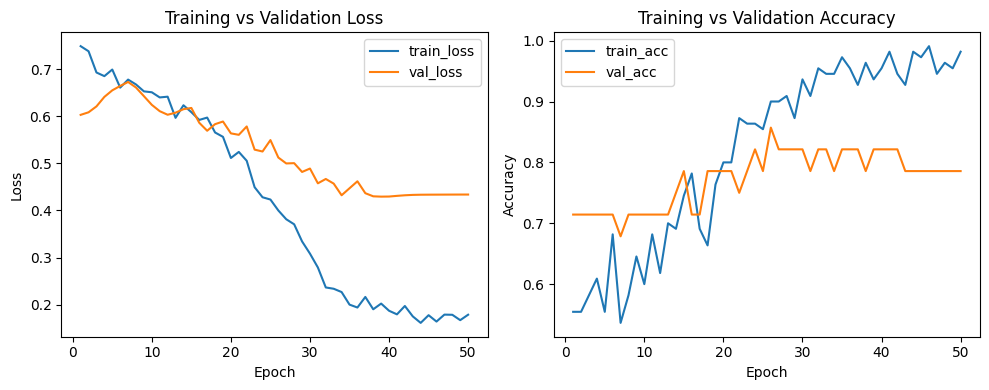

In [6]:
# ===== Cross-validation summary + training curve =====

import numpy as np
import matplotlib.pyplot as plt

print("===== Fold Results =====")

for r in fold_results:
    print(
        f"Fold {r['fold']} | "
        f"best_epoch={r['best_epoch']} | "
        f"val_loss={r['val_loss']:.6f} | "
        f"val_acc={r['val_acc']:.4f}"
    )

# ===== Mean ± Std =====
val_losses = [r["val_loss"] for r in fold_results]
val_accs = [r["val_acc"] for r in fold_results]

print("\n===== Cross-validation Mean ± Std =====")
print(f"val_loss: {np.mean(val_losses):.6f} ± {np.std(val_losses):.6f}")
print(f"val_acc : {np.mean(val_accs):.4f} ± {np.std(val_accs):.4f}")

# ===== Choose one fold to inspect training curves =====
fold_id = 0   # 可以改成 1,2,3,4 看不同 fold

h = fold_results[fold_id]["history"]

print(f"\n===== Training history for Fold {fold_results[fold_id]['fold']} =====")

print("train_loss:", h["train_loss"])
print("val_loss:", h["val_loss"])
print("train_acc:", h["train_acc"])
print("val_acc:", h["val_acc"])

# ===== Plot curves =====
epochs = range(1, len(h["train_loss"]) + 1)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(epochs, h["train_loss"], label="train_loss")
plt.plot(epochs, h["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, h["train_acc"], label="train_acc")
plt.plot(epochs, h["val_acc"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [7]:
config.epochs = check_point
config.model_path = best_model_path

print("Best model path:", join_drive_path("log", config.model_path))
print("Model checkpoint:", config.epochs)

Best model path: /root/ADHD-EEG-ViT-myversion/log/ieee-transformer_260309213635618066_5.pt
Model checkpoint: {'best_epoch': 40, 'best_val_loss': 0.22262566536664963, 'best_val_acc': 0.8888888888888888, 'history': {'train_loss': [0.7173099134649549, 0.6802117483956474, 0.6898018973214286, 0.6708078171525683, 0.655033814055579, 0.685339480638504, 0.6478065976074764, 0.6433458924293518, 0.6293791149343763, 0.6098509814058032, 0.6133849493094853, 0.5868298283645085, 0.5746931731700897, 0.5520001607281821, 0.5453397801944188, 0.5338320050920758, 0.5204460769891739, 0.49486479588917326, 0.49211159348487854, 0.4817878561360495, 0.4668001447405134, 0.45400378108024597, 0.3824175638811929, 0.35532706124441965, 0.3781512124197824, 0.3611889673130853, 0.3039774213518415, 0.2948352268763951, 0.24222673688616073, 0.2310853297156947, 0.21354883589914866, 0.20600283411996706, 0.18698972570044653, 0.1579972239477294, 0.12885196134448051, 0.13598755640642984, 0.11484116901244436, 0.078747058420309, 0.1

In [8]:
# clear_cache()

# trained_weights = torch.load(os.path.join(LOG_DIR, config.model_path), weights_only=True, map_location=device)

# model = ViTransformer(**model_param)
# model.load_state_dict(trained_weights)

import os
import torch

clear_cache()

# config.model_path 现在打印出来已经是一个绝对路径（Best model path 那行）
real_model_path = config.model_path
print("Loading model from:", real_model_path)
assert os.path.exists(real_model_path), f"Model file not found: {real_model_path}"

# 先加载到 CPU，避免加载阶段就占用/冲击 GPU
state_dict = torch.load(real_model_path, map_location="cpu")  # 不用 weights_only

model = ViTransformer(**model_param)
model.load_state_dict(state_dict)

# 再把模型搬到你之前选择的 device（cuda 或 cpu）
model = model.to(device)
model.eval()

Loading model from: ieee-transformer_260309213635618066_5.pt


ViTransformer(
  (chan_attn): ChannelAttention1D(
    (mlp): Sequential(
      (0): Linear(in_features=19, out_features=4, bias=True)
      (1): ReLU(inplace=True)
      (2): Identity()
      (3): Linear(in_features=4, out_features=19, bias=True)
      (4): Sigmoid()
    )
  )
  (proj): Conv1d(19, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (transformer): Transformer(
    (encoder): ModuleList(
      (0-3): 4 x AttentionBlock(
        (attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (feedforward): Sequential(
          (0): Linear(in_features=64, out_features=128, bias=True)
          (1): ReLU()
          (2): Linear(in_features=128, out_features=64, bias=True)
        )
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      )
    )
    (global_max_pool): Sequential(
      (0): AdaptiveMaxP

In [9]:
#test_data_path = join_drive_path("data", data_config.test)
#test_dataset = EEGDataset(test_data_path)

test_data_path = os.path.join(DATA_DIR, data_config.test)  # test.pt
test_data = torch.load(test_data_path, weights_only=True)
test_dataset = EEGDataset(test_data)

test_dataloader = DataLoader(test_dataset, batch_size=config.batch)

metrics = evaluate(model, device, test_dataloader)

print(f"Accuracy: {metrics['accuracy']:.3f}")
print(f"F1-Score: {metrics['f1-score']:.3f}")
print(f"Recall: {metrics['recall']:.3f}")
print(f"AUC: {metrics['auc']:.3f}")

Accuracy: 0.917
F1-Score: 0.927
Recall: 0.905
AUC: 0.919


Extracted features shape: (36, 32)
Labels shape: (36,)


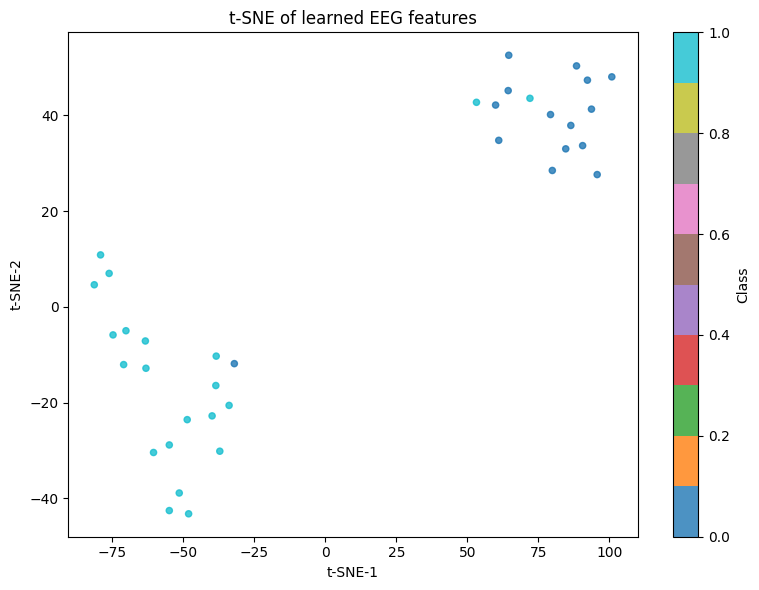

In [10]:
# 3.9===== t-SNE on learned features =====
# 放在“Cell 7（test_dataloader + evaluate）”后面即可
# 作用：提取 ViTransformer -> Transformer.fc[1] 的特征，并做 2D t-SNE 可视化

import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

model.eval()
model.to(device)

all_features = []
all_labels = []
_cached_feats = []

def _feat_hook(module, inputs, output):
    # output shape: [B, fc_hidden_dim]
    _cached_feats.append(output.detach().cpu())

# hook 到 Transformer 分类头第一层 Linear
# transformer.py 里 self.fc = [Flatten, Linear, ReLU, Dropout, Linear]
hook_handle = model.transformer.fc[1].register_forward_hook(_feat_hook)

with torch.no_grad():
    for batch in test_dataloader:
        # 兼容几种 batch 格式
        if isinstance(batch, (list, tuple)) and len(batch) == 2 and torch.is_tensor(batch[0]):
            x, y = batch
        elif isinstance(batch, dict):
            x, y = batch["data"], batch["label"]
        elif isinstance(batch, list) and len(batch) > 0 and isinstance(batch[0], dict):
            x = torch.stack([b["data"] for b in batch], dim=0)
            y = torch.tensor([b["label"] for b in batch])
        else:
            raise TypeError(f"Unrecognized batch structure: {type(batch)}")

        x = x.to(device)

        # 前向传播，触发 hook
        _ = model(x)

        # 取出当前 batch 的特征
        feat = _cached_feats.pop(0)   # [B, fc_hidden_dim]
        all_features.append(feat.numpy())
        all_labels.append(y.detach().cpu().numpy() if torch.is_tensor(y) else np.array(y))

hook_handle.remove()

features = np.concatenate(all_features, axis=0)
labels = np.concatenate(all_labels, axis=0)

print("Extracted features shape:", features.shape)
print("Labels shape:", labels.shape)

# 可选：先标准化，再做 t-SNE
features_std = StandardScaler().fit_transform(features)

# perplexity 要小于样本数，做个稳妥保护
n_samples = len(features_std)
perplexity = min(30, max(5, n_samples // 10))
if perplexity >= n_samples:
    perplexity = max(2, n_samples - 1)

tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    learning_rate="auto",
    init="pca",
    random_state=42
)

features_2d = tsne.fit_transform(features_std)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    features_2d[:, 0],
    features_2d[:, 1],
    c=labels,
    cmap="tab10",
    s=20,
    alpha=0.8
)

plt.title("t-SNE of learned EEG features")
plt.xlabel("t-SNE-1")
plt.ylabel("t-SNE-2")
plt.colorbar(scatter, label="Class")
plt.tight_layout()
plt.show()

In [11]:
json_path = join_drive_path("log", f"{config.name}_{config.id}.json")
log_json(
    json_path, config=config, data=data_config, model=model_config, metrics=metrics
)

{'config': {'name': 'ieee-transformer',
  'batch': 8,
  'epochs': {'best_epoch': 40,
   'best_val_loss': 0.22262566536664963,
   'best_val_acc': 0.8888888888888888,
   'history': {'train_loss': [0.7173099134649549,
     0.6802117483956474,
     0.6898018973214286,
     0.6708078171525683,
     0.655033814055579,
     0.685339480638504,
     0.6478065976074764,
     0.6433458924293518,
     0.6293791149343763,
     0.6098509814058032,
     0.6133849493094853,
     0.5868298283645085,
     0.5746931731700897,
     0.5520001607281821,
     0.5453397801944188,
     0.5338320050920758,
     0.5204460769891739,
     0.49486479588917326,
     0.49211159348487854,
     0.4817878561360495,
     0.4668001447405134,
     0.45400378108024597,
     0.3824175638811929,
     0.35532706124441965,
     0.3781512124197824,
     0.3611889673130853,
     0.3039774213518415,
     0.2948352268763951,
     0.24222673688616073,
     0.2310853297156947,
     0.21354883589914866,
     0.20600283411996706,
     

In [12]:
# 3.5改 检测channel-attention是否被启用取一个 batch 数据
batch = next(iter(test_dataloader))
print("batch type:", type(batch))
print("batch len:", len(batch) if hasattr(batch, "__len__") else None)

# 情况 A: (x, y) 或 [x, y]
if isinstance(batch, (list, tuple)) and len(batch) == 2 and torch.is_tensor(batch[0]):
    x, y = batch
    x = x.to(device)

# 情况 B: list[dict]
elif isinstance(batch, list) and len(batch) > 0 and isinstance(batch[0], dict):
    # 把 list[dict] 手动拼成 batch tensor（假设每个样本都有 "data"）
    x = torch.stack([b["data"] for b in batch], dim=0).to(device)

# 情况 C: dict（你原本写法适用）
elif isinstance(batch, dict):
    x = batch["data"].to(device)

else:
    raise TypeError(f"Unrecognized batch structure: {type(batch)} / example element: {type(batch[0]) if isinstance(batch, list) and batch else None}")

batch type: <class 'list'>
batch len: 2


In [13]:
#3.5 改
import re
from docx import Document

DOCX_PATH = "/root/ADHD-EEG-ViT-myversion/data_raw/Channel_Labels.docx"

def extract_channels_from_docx(docx_path):
    doc = Document(docx_path)
    tokens = []

    # 1) 读段落
    for p in doc.paragraphs:
        txt = p.text.strip()
        if txt:
            tokens.append(txt)

    # 2) 读表格（很多 docx 会把通道名放表格里）
    for table in doc.tables:
        for row in table.rows:
            for cell in row.cells:
                txt = cell.text.strip()
                if txt:
                    tokens.append(txt)

    # 3) 从文本里提取像 EEG 通道名的 token
    # 覆盖常见 10-20: Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2, F7, F8, T3/T4/T5/T6, T7/T8, P7/P8, Fz/Cz/Pz 等
    pattern = re.compile(r"\b(?:Fp[12]|AF[34z]?|F[1-8z]|FC[1-6z]|C[1-6z]|CP[1-6z]|P[1-8z]|PO[1-8z]|O[12z]|T[3-8]|TP[7-8]|FT[7-8])\b", re.IGNORECASE)

    found = []
    for txt in tokens:
        found.extend(pattern.findall(txt))

    # 4) 保留原出现顺序去重 + 统一大小写格式（首字母大写，p 保持小写的通用写法）
    def normalize(ch):
        ch = ch.strip()
        ch = ch[0].upper() + ch[1:]  # 粗略标准化
        ch = ch.replace("FP", "Fp")  # 处理 Fp
        return ch

    ch_names = []
    seen = set()
    for ch in found:
        ch = normalize(ch)
        if ch not in seen:
            seen.add(ch)
            ch_names.append(ch)

    return ch_names

ch_names = extract_channels_from_docx(DOCX_PATH)
print("Extracted channels:", ch_names)
print("Count:", len(ch_names))

Extracted channels: ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz']
Count: 19


Attention shape: torch.Size([4, 19])
Weight shape: (19,)


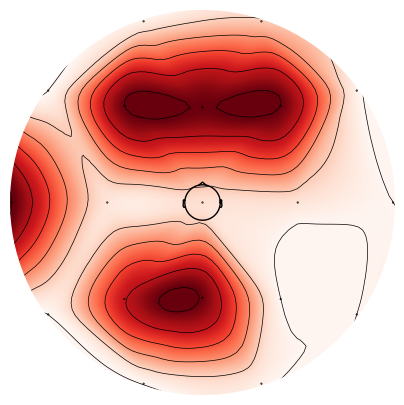

[7.03644827e-02 2.28118092e-01 9.99999881e-01 1.00000000e+00
 8.87671560e-02 1.03140041e-01 7.85165131e-01 1.14978492e-10
 1.09911207e-02 4.64201048e-02 6.24402197e-11 5.03786057e-02
 9.99993324e-01 4.65809762e-06 5.70603122e-04 1.66259534e-10
 9.91481662e-01 1.19649224e-01 9.82866764e-01]
min: 6.244022e-11
max: 1.0
range: 1.0
variance: 0.18166178


In [14]:
#3.5改
import os
import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt

# 1) 取 attention 权重（长度=19）
attn = model.last_channel_attn

if attn is None:
    raise RuntimeError("model.last_channel_attn is None，请先 forward 一次模型。")

# dynamic attention: [B, 19]
if attn.dim() == 2:
    w = attn.mean(dim=0).detach().cpu().numpy()

# static gating: [19]
elif attn.dim() == 1:
    w = attn.detach().cpu().numpy()

else:
    raise ValueError(f"Unexpected attention shape: {attn.shape}")

print("Attention shape:", attn.shape)
print("Weight shape:", w.shape)

assert len(ch_names) == 19 and len(w) == 19, (len(ch_names), w.shape)

# 2) 读 .ced 坐标文件（你项目根目录里那个）
CED_PATH = "/root/ADHD-EEG-ViT-myversion/data_raw/Standard-10-20-Cap19new.ced"
df = pd.read_csv(CED_PATH, sep="\t")

# 你 preprocess 用过的坐标转换：[-Y, X, Z]
ch_pos_all = {
    row["labels"]: [-row["Y"], row["X"], row["Z"]]
    for _, row in df[["labels", "X", "Y", "Z"]].iterrows()
}

# 3) 只取你这 19 个通道的位置
missing = [ch for ch in ch_names if ch not in ch_pos_all]
if missing:
    raise ValueError(f"Channels not found in CED: {missing}\n"
                     f"Tip: 可能是 T3/T4 vs T7/T8 命名差异，需要做 rename 映射。")

pos = {ch: ch_pos_all[ch] for ch in ch_names}
montage = mne.channels.make_dig_montage(ch_pos=pos, coord_frame="head")

# 4) 构造 info 并画 topomap
info = mne.create_info(ch_names=ch_names, sfreq=250, ch_types="eeg")
info.set_montage(montage)

fig, ax = plt.subplots(figsize=(5, 5))
mne.viz.plot_topomap(w, info, axes=ax, contours=6, show=True)
ax.set_title("EEG Channel Attention Topomap")
plt.show()
print(w)
print("min:", w.min())
print("max:", w.max())
print("range:", w.max() - w.min())
print("variance:", np.var(w))